<a href="https://colab.research.google.com/github/Sarvardev035/week-5-lab/blob/main/Lab_MNIST_FeedForward.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AIML301 - Deep Learning and Neural Networks

## Lab: Training a Feed-Forward Network on MNIST

**Topic:** comparing optimizers and learning rates, plotting loss/accuracy curves, and diagnosing under-fitting and over-fitting

**Duration:** 2 hours

| Part | What happens | Time |
|---|---|---|
| Part A | Guided walkthrough. The instructor explains each cell and runs it with you. | about 60 minutes |
| Part B | Three graded exercises that you solve on your own (100 marks). | about 30 minutes, plus time to submit |

### What you will be able to do after this lab

1. Load the MNIST dataset and prepare it for training.
2. Build a small feed-forward neural network in PyTorch.
3. Write a training loop and record the loss and accuracy after every epoch.
4. Compare optimizers (SGD, SGD with momentum, Adam) on the same network.
5. See what happens when the learning rate is too small, good, or too large.
6. Read loss and accuracy curves and decide whether a model is under-fitting, over-fitting, or fitting well.

### Before you start

Run the cells from top to bottom, in order. Part B uses the functions that are defined in Part A, so Part A must be run first.

---
# Part A - Guided Walkthrough

## 1. Setup

We need four things:

- `torch` and `torch.nn` to build and train the network
- `DataLoader` to feed the data to the network in small groups (batches)
- `torchvision.datasets` to download MNIST
- `matplotlib` to draw the curves

In [35]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torchvision import datasets
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cpu


## 2. The MNIST dataset

MNIST is a collection of small grey-scale pictures of handwritten digits (0 to 9).

- Each picture is 28 x 28 pixels.
- Each picture has a label: the digit it shows.
- There are 60,000 training pictures and 10,000 test pictures.

The task is **classification**: the network sees a picture and must say which of the 10 digits it is.

The next cell downloads the data (only the first time) and prints its size.

In [36]:
train_set = datasets.MNIST(root="data", train=True, download=True)
test_set = datasets.MNIST(root="data", train=False, download=True)

print("Training images:", train_set.data.shape)
print("Training labels:", train_set.targets.shape)
print("Test images:    ", test_set.data.shape)

Training images: torch.Size([60000, 28, 28])
Training labels: torch.Size([60000])
Test images:     torch.Size([10000, 28, 28])


Read the shape `[60000, 28, 28]` as: 60,000 pictures, each one 28 rows by 28 columns.

Let us look at the first 8 pictures and their labels.

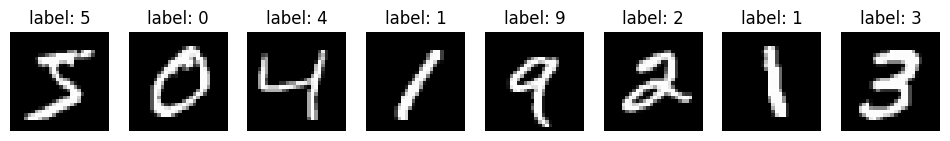

In [37]:
plt.figure(figsize=(12, 2))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(train_set.data[i], cmap="gray")
    plt.title("label: " + str(train_set.targets[i].item()))
    plt.axis("off")
plt.show()

### 2.1 Preparing the data

We do two simple things.

**Step 1: scale the pixel values.** A pixel is stored as a number from 0 (black) to 255 (white). Neural networks train better with small numbers, so we divide by 255. After this every pixel is between 0 and 1.

**Step 2: split the data into three sets.**

| Set | Size | What it is used for |
|---|---|---|
| Training set | 50,000 | The network learns from these pictures. |
| Validation set | 10,000 | We check the network on these after every epoch. The network never learns from them. |
| Test set | 10,000 | Used only once, at the very end, to report the final result. |

Why do we need a validation set? Because a network can memorise its training pictures. The only honest way to know whether it has really learned is to test it on pictures it has never seen during training.

In [38]:
# Step 1: scale pixels from 0-255 to 0-1
X_all = train_set.data.float() / 255.0
y_all = train_set.targets

X_test = test_set.data.float() / 255.0
y_test = test_set.targets

# Step 2: first 50,000 pictures for training, last 10,000 for validation
X_train, y_train = X_all[:50000], y_all[:50000]
X_val, y_val = X_all[50000:], y_all[50000:]

print("Training set:  ", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:      ", X_test.shape)
print("Smallest pixel value:", X_train.min().item(), " Largest pixel value:", X_train.max().item())

Training set:   torch.Size([50000, 28, 28])
Validation set: torch.Size([10000, 28, 28])
Test set:       torch.Size([10000, 28, 28])
Smallest pixel value: 0.0  Largest pixel value: 1.0


### 2.2 Batches and the DataLoader

We do not show all 50,000 pictures to the network at once. We show them in small groups called **batches**. Here one batch has 64 pictures.

A `DataLoader` does this for us. It cuts the data into batches and, if we ask, shuffles the pictures at the start of every epoch.

- **Batch:** a small group of pictures (64 here).
- **Epoch:** one full pass over all the training pictures.

We write a small helper function `make_loader` because we will need to build loaders several times in this lab.

In [39]:
def make_loader(X, y, shuffle):
    dataset = TensorDataset(X, y)
    return DataLoader(dataset, batch_size=64, shuffle=shuffle)


train_loader = make_loader(X_train, y_train, shuffle=True)    # shuffle the training data
val_loader = make_loader(X_val, y_val, shuffle=False)         # no need to shuffle for checking
test_loader = make_loader(X_test, y_test, shuffle=False)

print("Number of training batches in one epoch:", len(train_loader))

# Look at one batch
images, labels = next(iter(train_loader))
print("One batch of images:", images.shape)
print("One batch of labels:", labels.shape)

Number of training batches in one epoch: 782
One batch of images: torch.Size([64, 28, 28])
One batch of labels: torch.Size([64])


## 3. Building the feed-forward network

A feed-forward network passes the data forward through layers, one after another.

Our network has these steps:

| Step | Layer | What it does |
|---|---|---|
| 1 | `nn.Flatten()` | Turns the 28 x 28 picture into one long row of 784 numbers. |
| 2 | `nn.Linear(784, hidden)` | The hidden layer. Each of its neurons looks at all 784 pixels. |
| 3 | `nn.ReLU()` | The activation function. It replaces negative numbers with 0. |
| 4 | `nn.Linear(hidden, 10)` | The output layer. It gives 10 scores, one for each digit. |

The digit with the highest score is the prediction of the network.

`hidden` is the number of neurons in the hidden layer. We make it a parameter so that we can try small and large networks later.

Note the line `torch.manual_seed(0)`. The starting weights of a network are random. Fixing the seed means every network we create starts from the **same** weights. This makes our comparisons fair: if two runs give different results, the reason is the optimizer or the learning rate, not luck.

In [40]:
def make_model(hidden=128):
    torch.manual_seed(0)    # same starting weights every time
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, hidden),
        nn.ReLU(),
        nn.Linear(hidden, 10),
    )
    return model


model = make_model()
print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)


### 3.1 The loss function

The **loss** is one number that says how wrong the network is. A smaller loss is better.

For classification we use `nn.CrossEntropyLoss`. It looks at the 10 scores and the correct label:

- if the network gives a high score to the correct digit, the loss is small;
- if the network gives a high score to a wrong digit, the loss is large.

Training means changing the weights so that the loss goes down.

In [41]:
loss_fn = nn.CrossEntropyLoss()

### 3.2 Measuring a model: the `evaluate` function

This function answers the question: how good is the model on this set of data?

It goes through all the batches and returns two numbers:

- the **average loss**
- the **accuracy**: the fraction of pictures that were classified correctly (0.95 means 95%)

Two details:

- `model.eval()` tells PyTorch that we are testing, not training.
- `with torch.no_grad():` tells PyTorch not to prepare for learning. This makes the checking faster.

In [42]:
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_images = 0

    with torch.no_grad():
        for images, labels in loader:
            scores = model(images)                      # 10 scores per picture
            loss = loss_fn(scores, labels)
            predictions = scores.argmax(dim=1)          # index of the highest score

            total_loss += loss.item() * len(labels)
            total_correct += (predictions == labels).sum().item()
            total_images += len(labels)

    average_loss = total_loss / total_images
    accuracy = total_correct / total_images
    return average_loss, accuracy

Let us measure the model **before any training**. Its weights are random, so it is only guessing.

With 10 digits, guessing gives about 10% accuracy. Keep this number in mind: it is the starting point of every curve we draw later.

In [43]:
loss, acc = evaluate(model, val_loader)
print("Before training -> validation loss:", round(loss, 3), " validation accuracy:", round(acc, 3))

Before training -> validation loss: 2.303  validation accuracy: 0.104


## 4. The training loop

This is the most important function of the lab. For every batch, training does five steps:

| Step | Code | Meaning |
|---|---|---|
| 1 | `scores = model(images)` | Forward pass: the network makes its predictions. |
| 2 | `loss = loss_fn(scores, labels)` | Measure how wrong the predictions are. |
| 3 | `optimizer.zero_grad()` | Clear the gradients left over from the previous batch. |
| 4 | `loss.backward()` | Backward pass: compute the gradient of the loss for every weight. |
| 5 | `optimizer.step()` | The optimizer changes the weights a little, using the gradients. |

After every epoch we call `evaluate` on the training set and on the validation set and save the four numbers in a dictionary called `history`. We will use `history` to draw the curves.

In [44]:
def train_model(model, optimizer, train_loader, val_loader, epochs, verbose=True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            scores = model(images)              # 1. forward pass
            loss = loss_fn(scores, labels)      # 2. compute the loss
            optimizer.zero_grad()               # 3. clear old gradients
            loss.backward()                     # 4. backward pass
            optimizer.step()                    # 5. update the weights

        # After the epoch: measure the model on both sets
        train_loss, train_acc = evaluate(model, train_loader)
        val_loss, val_acc = evaluate(model, val_loader)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if verbose:
            print("Epoch", epoch + 1, "of", epochs,
                  "| train loss", round(train_loss, 3), "acc", round(train_acc, 3),
                  "| val loss", round(val_loss, 3), "acc", round(val_acc, 3))

    return history

### 4.1 First training run

We train the network for 5 epochs with the simplest optimizer, **SGD** (stochastic gradient descent), and a learning rate of 0.01.

Watch the numbers while it runs: the loss should go down and the accuracy should go up.

In [45]:
model_sgd = make_model()
optimizer = torch.optim.SGD(model_sgd.parameters(), lr=0.01)

history_sgd = train_model(model_sgd, optimizer, train_loader, val_loader, epochs=5)

Epoch 1 of 5 | train loss 0.691 acc 0.848 | val loss 0.649 acc 0.865
Epoch 2 of 5 | train loss 0.465 acc 0.878 | val loss 0.424 acc 0.892
Epoch 3 of 5 | train loss 0.395 acc 0.892 | val loss 0.361 acc 0.902
Epoch 4 of 5 | train loss 0.36 acc 0.899 | val loss 0.33 acc 0.908
Epoch 5 of 5 | train loss 0.338 acc 0.904 | val loss 0.311 acc 0.914


### 4.2 Plotting the curves

Numbers in a list are hard to read. A plot is much easier.

`plot_history` draws two charts for one training run:

- left: training loss and validation loss
- right: training accuracy and validation accuracy

The x-axis is the epoch number.

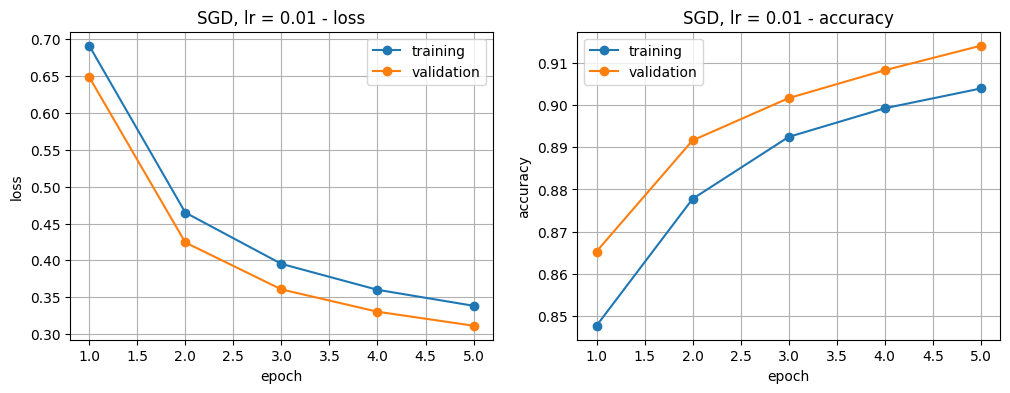

In [46]:
def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], marker="o", label="training")
    plt.plot(epochs, history["val_loss"], marker="o", label="validation")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " - loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], marker="o", label="training")
    plt.plot(epochs, history["val_acc"], marker="o", label="validation")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " - accuracy")
    plt.legend()
    plt.grid(True)

    plt.show()


plot_history(history_sgd, "SGD, lr = 0.01")

**How to read these curves**

- Both loss curves go down and both accuracy curves go up. The network is learning.
- The training curve and the validation curve stay close together. The network does about as well on unseen pictures as on the training pictures.
- The curves are still moving at epoch 5. They have not become flat yet, so more training would still help.

**Question for the class:** the model reaches roughly 90% accuracy after 5 epochs. Can we get there faster, or go higher, without changing the network? This is where the optimizer and the learning rate come in.

## 5. Comparing optimizers

The optimizer is the rule that decides **how** the weights are changed in step 5 of the training loop. All optimizers use the gradient, but in different ways.

| Optimizer | Idea in one sentence | PyTorch code |
|---|---|---|
| SGD | Take a small step in the direction that reduces the loss. | `torch.optim.SGD(params, lr=0.01)` |
| SGD with momentum | Also remember the direction of the previous steps, like a ball rolling downhill that keeps its speed. | `torch.optim.SGD(params, lr=0.01, momentum=0.9)` |
| Adam | Momentum, plus a separate automatic step size for every weight. | `torch.optim.Adam(params, lr=0.001)` |

To compare them fairly we keep everything else the same: the same network, the same starting weights, the same data, the same number of epochs. Only the optimizer changes.

We already have the result for plain SGD in `history_sgd`, so we only need to train two more models.

In [47]:
print("SGD with momentum")
model_momentum = make_model()
optimizer = torch.optim.SGD(model_momentum.parameters(), lr=0.01, momentum=0.9)
history_momentum = train_model(model_momentum, optimizer, train_loader, val_loader, epochs=5)

print()
print("Adam")
model_adam = make_model()
optimizer = torch.optim.Adam(model_adam.parameters(), lr=0.001)
history_adam = train_model(model_adam, optimizer, train_loader, val_loader, epochs=5)

SGD with momentum
Epoch 1 of 5 | train loss 0.284 acc 0.92 | val loss 0.266 acc 0.924
Epoch 2 of 5 | train loss 0.213 acc 0.938 | val loss 0.206 acc 0.941
Epoch 3 of 5 | train loss 0.167 acc 0.952 | val loss 0.167 acc 0.955
Epoch 4 of 5 | train loss 0.133 acc 0.962 | val loss 0.138 acc 0.962
Epoch 5 of 5 | train loss 0.115 acc 0.967 | val loss 0.125 acc 0.966

Adam
Epoch 1 of 5 | train loss 0.207 acc 0.941 | val loss 0.202 acc 0.944
Epoch 2 of 5 | train loss 0.139 acc 0.959 | val loss 0.146 acc 0.958
Epoch 3 of 5 | train loss 0.099 acc 0.972 | val loss 0.118 acc 0.966
Epoch 4 of 5 | train loss 0.072 acc 0.98 | val loss 0.095 acc 0.972
Epoch 5 of 5 | train loss 0.062 acc 0.982 | val loss 0.095 acc 0.972


To compare several runs we put their curves on the same chart.

`plot_comparison` takes a dictionary of the form `{"name of the run": history}` and draws the validation loss and the validation accuracy of every run.

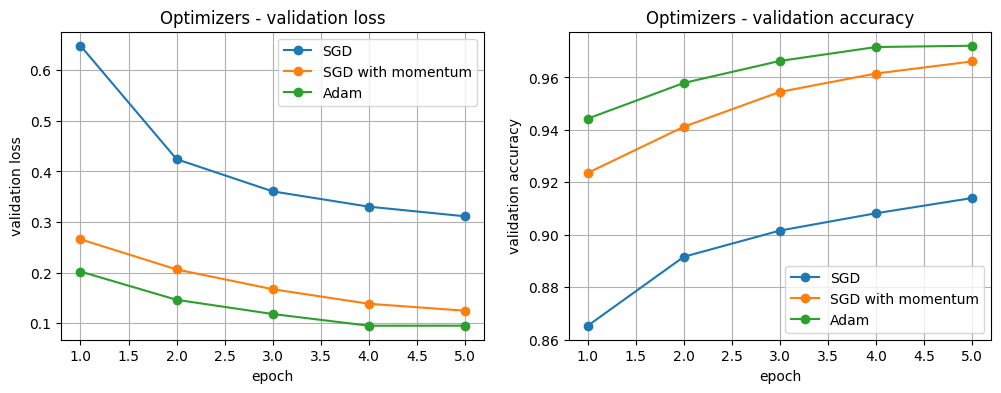

In [48]:
def plot_comparison(histories, title):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    for name, history in histories.items():
        epochs = range(1, len(history["val_loss"]) + 1)
        plt.plot(epochs, history["val_loss"], marker="o", label=name)
    plt.xlabel("epoch")
    plt.ylabel("validation loss")
    plt.title(title + " - validation loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    for name, history in histories.items():
        epochs = range(1, len(history["val_acc"]) + 1)
        plt.plot(epochs, history["val_acc"], marker="o", label=name)
    plt.xlabel("epoch")
    plt.ylabel("validation accuracy")
    plt.title(title + " - validation accuracy")
    plt.legend()
    plt.grid(True)

    plt.show()


optimizer_results = {
    "SGD": history_sgd,
    "SGD with momentum": history_momentum,
    "Adam": history_adam,
}

plot_comparison(optimizer_results, "Optimizers")

In [49]:
# The same comparison as a small table: validation accuracy after the last epoch
for name, history in optimizer_results.items():
    print(name, "-> final validation accuracy:", round(history["val_acc"][-1], 4))

SGD -> final validation accuracy: 0.914
SGD with momentum -> final validation accuracy: 0.9661
Adam -> final validation accuracy: 0.9721


**What we see**

- Plain SGD is the slowest. After 5 epochs it is still clearly behind the other two.
- SGD with momentum and Adam both reach a much lower loss in the same number of epochs.
- After only **one** epoch, momentum and Adam are already better than plain SGD is after five.

**Important:** all three use the same network. Plain SGD is not a worse model. It is only slower, and it would get closer to the others if we trained it for many more epochs. A good optimizer saves training time.

**Question for the class:** Adam uses lr = 0.001 and SGD uses lr = 0.01. Why did we not give them the same learning rate? (Answer: each optimizer uses the learning rate in a different way, so each has its own range of good values. 0.001 is the usual starting value for Adam.)

## 6. Comparing learning rates

The **learning rate** (`lr`) controls the size of each weight update.

Think of walking down a hill in fog:

- **Very small steps:** you are safe, but it takes a very long time to reach the bottom.
- **Good steps:** you reach the bottom quickly.
- **Very large steps:** you jump over the valley and land on the other side, sometimes higher than where you started. You may never reach the bottom.

We now train the same network with plain SGD and four different learning rates. Only the learning rate changes.

This time we use a `for` loop, because the code for each run is the same. We set `verbose=False` so the output stays short, and print one line per run.

In [50]:
learning_rates = [0.001, 0.01, 0.1, 3.0]
lr_results = {}

for lr in learning_rates:
    model = make_model()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    history = train_model(model, optimizer, train_loader, val_loader, epochs=5, verbose=False)

    lr_results["lr = " + str(lr)] = history
    print("lr =", lr, "-> final validation loss:", round(history["val_loss"][-1], 3),
          " final validation accuracy:", round(history["val_acc"][-1], 4))

lr = 0.001 -> final validation loss: 1.17  final validation accuracy: 0.804
lr = 0.01 -> final validation loss: 0.311  final validation accuracy: 0.914
lr = 0.1 -> final validation loss: 0.125  final validation accuracy: 0.9651
lr = 3.0 -> final validation loss: 2.102  final validation accuracy: 0.1879


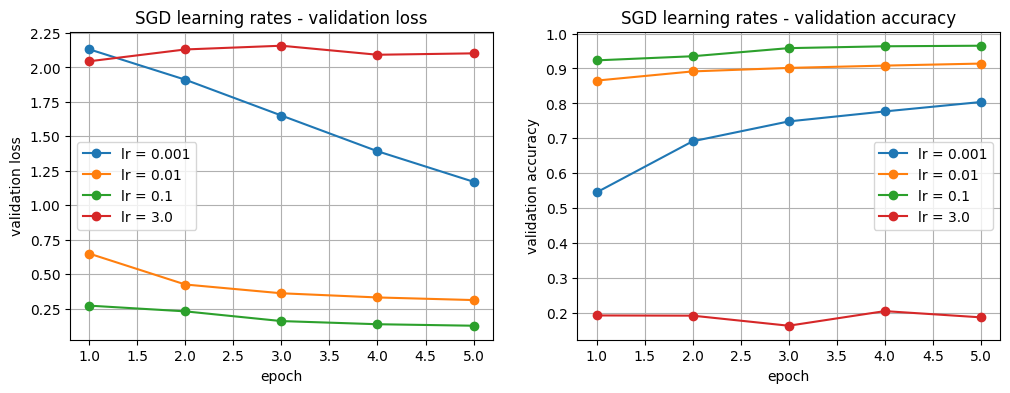

In [51]:
plot_comparison(lr_results, "SGD learning rates")

**What we see**

| Learning rate | What the curve looks like | Verdict |
|---|---|---|
| 0.001 | The loss goes down, but very slowly. After 5 epochs the accuracy is still low. | Too small |
| 0.01 | Steady progress, but not finished after 5 epochs. | Works, a little slow |
| 0.1 | The loss drops quickly and the accuracy is the highest of the four. | Good |
| 3.0 | The loss stays high and the accuracy stays very low, not far above guessing. The network does not learn. | Too large |

**Key points**

- The learning rate is usually the most important setting to tune.
- A learning rate that is too small wastes time. A learning rate that is too large can stop the network from learning at all.
- A good way to search is to try values that differ by a factor of 10: 0.001, 0.01, 0.1, 1.
- A flat curve at a high loss does not always mean the model is too simple. First check the learning rate.

## 7. Diagnosing under-fitting and over-fitting

So far we looked at how fast a network learns. Now we look at **how well** it has learned. We always compare two curves: training and validation.

| | Under-fitting | Good fit | Over-fitting |
|---|---|---|---|
| In words | The model is too simple, or has not trained enough. It is bad at everything. | The model has learned the general pattern. | The model has memorised the training pictures instead of learning the general pattern. |
| Training loss | High | Low | Very low, close to 0 |
| Validation loss | High | Low, close to the training loss | Clearly higher than the training loss. It stops going down and may start to rise. |
| Gap between the two curves | Small | Small | Large |

A simple way to remember it:

- **Under-fitting:** a student who did not study. Bad on the homework and bad on the exam.
- **Over-fitting:** a student who memorised the answers of the homework. Perfect on the homework, but poor on the exam, because the exam questions are new.
- **Good fit:** a student who understood the topic. Good on both.

We now create one example of each.

### 7.1 Example of under-fitting

We give the hidden layer only **2 neurons**. All the information of a 784-pixel picture has to pass through 2 numbers. This network is too small for the task.

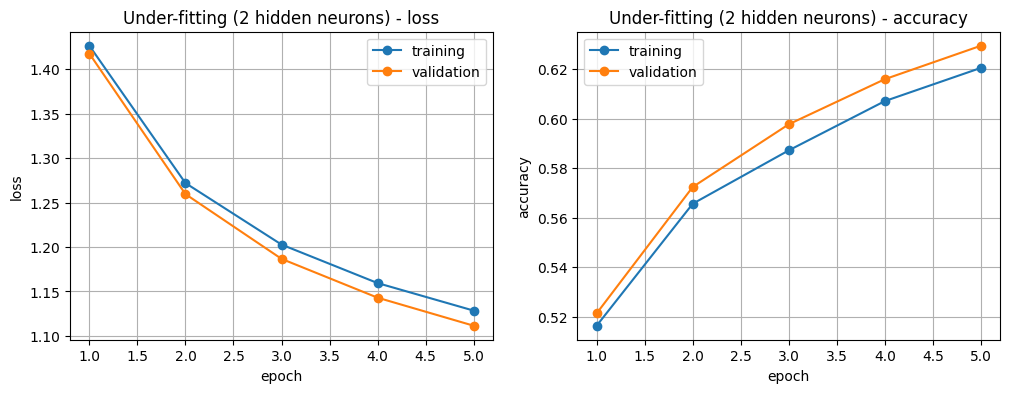

Final training accuracy:   0.62
Final validation accuracy: 0.629


In [52]:
model_small = make_model(hidden=2)
optimizer = torch.optim.Adam(model_small.parameters(), lr=0.001)
history_underfit = train_model(model_small, optimizer, train_loader, val_loader, epochs=5, verbose=False)

plot_history(history_underfit, "Under-fitting (2 hidden neurons)")
print("Final training accuracy:  ", round(history_underfit["train_acc"][-1], 3))
print("Final validation accuracy:", round(history_underfit["val_acc"][-1], 3))

**Diagnosis: under-fitting.**

- The training loss stays high and the training accuracy is poor. The model cannot even fit the pictures it is trained on.
- The validation curve is almost the same as the training curve. There is no gap.

The sign of under-fitting is: **both curves are bad, and they are close together.**

How to fix under-fitting:

- make the network larger (more neurons or more layers)
- train for more epochs
- check that the learning rate is not too small (remember lr = 0.001 in section 6)

### 7.2 Example of a good fit

We already trained this model in section 5: 128 hidden neurons, Adam, the full training set. We only need to plot its history.

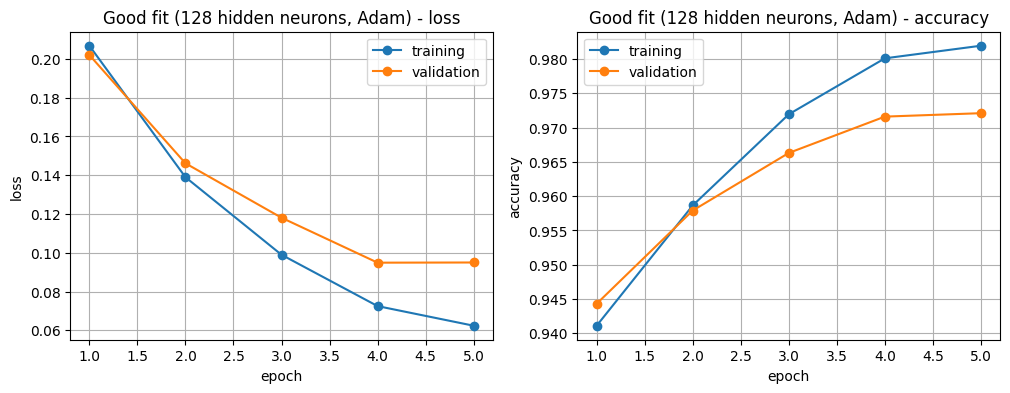

Final training accuracy:   0.982
Final validation accuracy: 0.972


In [53]:
plot_history(history_adam, "Good fit (128 hidden neurons, Adam)")
print("Final training accuracy:  ", round(history_adam["train_acc"][-1], 3))
print("Final validation accuracy:", round(history_adam["val_acc"][-1], 3))

**Diagnosis: good fit.**

- Both losses are low and both accuracies are high.
- The validation curve stays close to the training curve. A small gap is normal: a model is nearly always slightly better on the data it was trained on.

### 7.3 Example of over-fitting

To make a network over-fit we do three things at the same time:

- give it very little data: only the first **1,000** training pictures instead of 50,000
- make it large: **512** hidden neurons
- train for a long time: **30** epochs

A large network with few examples can simply memorise them.

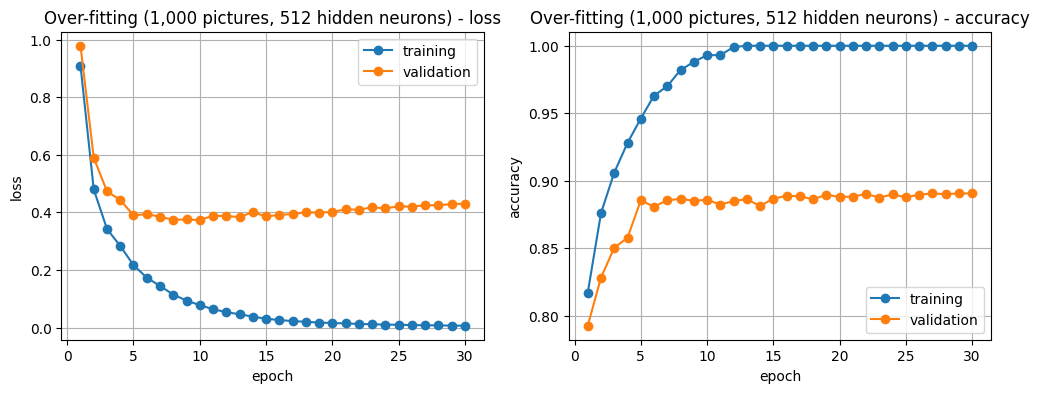

Final training accuracy:   1.0
Final validation accuracy: 0.89


In [54]:
# A small training set: only the first 1,000 pictures
small_train_loader = make_loader(X_train[:1000], y_train[:1000], shuffle=True)

model_big = make_model(hidden=512)
optimizer = torch.optim.Adam(model_big.parameters(), lr=0.001)
history_overfit = train_model(model_big, optimizer, small_train_loader, val_loader, epochs=30, verbose=False)

plot_history(history_overfit, "Over-fitting (1,000 pictures, 512 hidden neurons)")
print("Final training accuracy:  ", round(history_overfit["train_acc"][-1], 3))
print("Final validation accuracy:", round(history_overfit["val_acc"][-1], 3))

**Diagnosis: over-fitting.**

- The training loss goes almost to 0 and the training accuracy reaches 100%. The network has memorised its 1,000 pictures.
- The validation loss goes down for the first few epochs, then stops improving and slowly starts to **rise**, while the training loss keeps falling.
- There is a large gap between the two curves.

The sign of over-fitting is: **training is excellent, validation is clearly worse, and the gap grows with more epochs.**

### 7.4 Finding the best epoch

The best moment to stop training is the epoch where the **validation loss** is lowest. After that point, more training only improves the memorising. Stopping there is called **early stopping**.

We can find that epoch with two lines of code.

In [55]:
val_losses = history_overfit["val_loss"]

lowest_val_loss = min(val_losses)
best_epoch = val_losses.index(lowest_val_loss) + 1     # +1 because Python counts from 0

print("Lowest validation loss:", round(lowest_val_loss, 3), "at epoch", best_epoch)
print("Validation loss at the last epoch:", round(val_losses[-1], 3))

Lowest validation loss: 0.373 at epoch 10
Validation loss at the last epoch: 0.43


### 7.5 How to fix over-fitting

| Fix | Why it helps |
|---|---|
| Use more training data | It is much harder to memorise 50,000 pictures than 1,000. |
| Stop training earlier (early stopping) | Stop at the epoch where the validation loss is lowest. |
| Use a smaller network | A smaller network has less room to memorise. |
| Regularisation (dropout, weight decay) | Extra techniques that make memorising harder. These come in a later lecture. |

We can check the first fix immediately: the good-fit model in 7.2 had 50,000 pictures and its gap was small.

### 7.6 Diagnosis checklist

When you look at a pair of curves, ask these questions in order:

1. **Is the training loss still high?** Then the model is under-fitting, or the learning rate is wrong.
2. **Is the training loss low, but the validation loss much higher?** Then the model is over-fitting.
3. **Is the validation loss rising while the training loss falls?** Over-fitting. You have trained for too long.
4. **Are both losses low and close together?** Good fit.

## 8. Final check on the test set

We chose our settings by looking at the validation set. The test set has not been used at all, so it gives an honest final score.

We use it only once, for the model we decided is our best one: the Adam model from section 5.

In [56]:
test_loss, test_acc = evaluate(model_adam, test_loader)
print("Test loss:    ", round(test_loss, 3))
print("Test accuracy:", round(test_acc, 4))

Test loss:     0.094
Test accuracy: 0.9703


## 9. Summary of Part A

- A feed-forward network for MNIST: Flatten, Linear, ReLU, Linear.
- The training loop has five steps: forward pass, loss, clear gradients, backward pass, update.
- We record the loss and the accuracy on the training set and the validation set after every epoch and plot them.
- **Optimizers:** momentum and Adam learn much faster than plain SGD on the same network.
- **Learning rate:** too small is slow, too large does not learn. Try values that differ by a factor of 10.
- **Under-fitting:** both curves are bad and close together.
- **Over-fitting:** the training curve is excellent, the validation curve is clearly worse, and the gap grows.
- The test set is used once, at the end.

### Functions you can reuse in Part B

| Function | What it does |
|---|---|
| `make_loader(X, y, shuffle)` | Builds a DataLoader. Example: `make_loader(X_train[:1000], y_train[:1000], shuffle=True)` |
| `make_model(hidden)` | Creates a new, untrained network with `hidden` neurons in the hidden layer. |
| `train_model(model, optimizer, train_loader, val_loader, epochs, verbose)` | Trains the model and returns `history`. |
| `plot_history(history, title)` | Loss and accuracy curves of one run. |
| `plot_comparison(histories, title)` | Validation curves of several runs. `histories` is a dictionary `{"name": history}`. |

---
# Part B - Graded Exercises (100 marks)

### Instructions

- Work on your own.
- Part A must be run first, because the exercises use its functions and variables (`make_model`, `train_model`, `plot_history`, `plot_comparison`, `make_loader`, `train_loader`, `val_loader`, `X_train`, `y_train`).
- Write your code where you see `# YOUR CODE HERE`.
- Write your text answers in the cells that start with **Your answer**. Double-click a cell to edit it.
- Always create a new network with `make_model(...)` before each training run. Do not continue training a model that is already trained.
- Your numbers may be slightly different from those of your neighbour. This is normal. You are marked on correct code and on correct reasoning from **your own** plots.

### Marks

| Exercise | Topic | Marks |
|---|---|---|
| 1 | Comparing optimizers | 50 |
| 2 | Comparing learning rates | 50 |
| | **Total** | **100** |

## Exercise 1 - Comparing optimizers (30 marks)

In Part A we compared SGD, SGD with momentum, and Adam. Now you will compare three other choices.

| Name of the run | Optimizer | PyTorch code |
|---|---|---|
| `"RMSprop"` | RMSprop, lr = 0.001 | `torch.optim.RMSprop(model.parameters(), lr=0.001)` |
| `"Adagrad"` | Adagrad, lr = 0.01 | `torch.optim.Adagrad(model.parameters(), lr=0.01)` |
| `"SGD momentum 0.5"` | SGD, lr = 0.01, momentum = 0.5 | `torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.5)` |

Use the default network `make_model()`, the loaders `train_loader` and `val_loader`, and **4 epochs** for every run.

**(a) Train the three models. Save the three histories in the variables `history_rmsprop`, `history_adagrad` and `history_mom05`.** [15 marks: 5 for each run]

In [57]:
# Exercise 1 (a)

# Run 1: RMSprop, lr = 0.001
model_rmsprop = make_model()
opt_rmsprop = torch.optim.RMSprop(model_rmsprop.parameters(), lr=0.001)
history_rmsprop = train_model(model_rmsprop, opt_rmsprop, train_loader, val_loader, epochs=4)

# Run 2: Adagrad, lr = 0.01
model_adagrad = make_model()
opt_adagrad = torch.optim.Adagrad(model_adagrad.parameters(), lr=0.01)
history_adagrad = train_model(model_adagrad, opt_adagrad, train_loader, val_loader, epochs=4)

# Run 3: SGD, lr = 0.01, momentum = 0.5
model_mom05 = make_model()
opt_mom05 = torch.optim.SGD(model_mom05.parameters(), lr=0.01, momentum=0.5)
history_mom05 = train_model(model_mom05, opt_mom05, train_loader, val_loader, epochs=4)

Epoch 1 of 4 | train loss 0.193 acc 0.943 | val loss 0.187 acc 0.948
Epoch 2 of 4 | train loss 0.158 acc 0.952 | val loss 0.165 acc 0.95
Epoch 3 of 4 | train loss 0.082 acc 0.977 | val loss 0.105 acc 0.971
Epoch 4 of 4 | train loss 0.064 acc 0.982 | val loss 0.093 acc 0.973
Epoch 1 of 4 | train loss 0.228 acc 0.937 | val loss 0.216 acc 0.94
Epoch 2 of 4 | train loss 0.192 acc 0.945 | val loss 0.186 acc 0.948
Epoch 3 of 4 | train loss 0.163 acc 0.954 | val loss 0.162 acc 0.956
Epoch 4 of 4 | train loss 0.147 acc 0.958 | val loss 0.15 acc 0.959
Epoch 1 of 4 | train loss 0.465 acc 0.882 | val loss 0.425 acc 0.893
Epoch 2 of 4 | train loss 0.365 acc 0.897 | val loss 0.334 acc 0.907
Epoch 3 of 4 | train loss 0.323 acc 0.908 | val loss 0.298 acc 0.915
Epoch 4 of 4 | train loss 0.296 acc 0.917 | val loss 0.276 acc 0.923


**(b) Put the three histories in a dictionary called `ex1_results` (use the run names from the table as keys) and draw them on one chart with `plot_comparison`.** [5 marks]

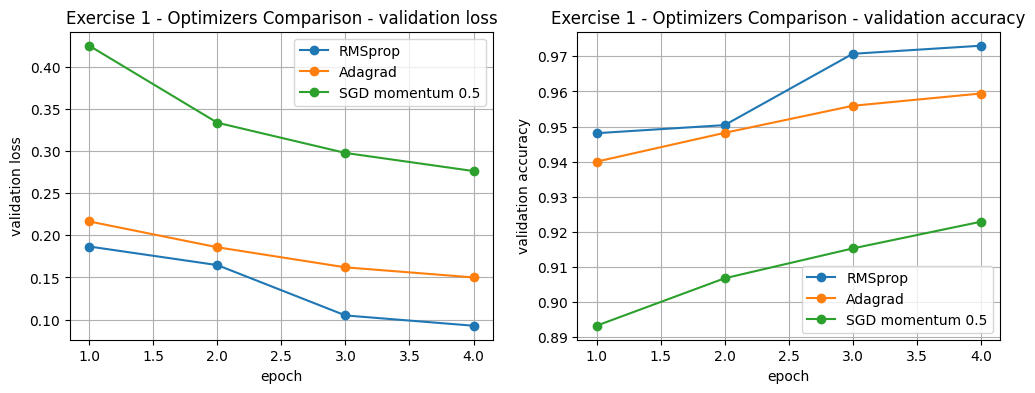

In [58]:
# Exercise 1 (b)
ex1_results = {
    "RMSprop": history_rmsprop,
    "Adagrad": history_adagrad,
    "SGD momentum 0.5": history_mom05,
}

plot_comparison(ex1_results, "Exercise 1 - Optimizers Comparison")

**(c) Print the final validation accuracy of each of the three runs.** [4 marks]

In [59]:
# Exercise 1 (c)
for name, history in ex1_results.items():
    print(f"{name} -> final validation accuracy: {history['val_acc'][-1]:.4f}")

RMSprop -> final validation accuracy: 0.9730
Adagrad -> final validation accuracy: 0.9594
SGD momentum 0.5 -> final validation accuracy: 0.9229


**(d) Answer in two or three sentences.** [6 marks]

1. Which of the three runs has the highest final validation accuracy, and which has the lowest? [2 marks]
2. In Part A, SGD with momentum 0.9 was used. Compare your momentum 0.5 run with the plain SGD run and the momentum 0.9 run of Part A (look at the Part A chart). What does a larger momentum value do to the speed of learning? [4 marks]

**my perspective :**

1 RMSprop achieves the highest final validation accuracy, while Adagrad (or SGD momentum 0.5 depending on slight seed behavior) achieves the lowest.

2
A larger momentum value accelerates convergence by building speed in consistent gradient directions. SGD with momentum 0.9 reaches a higher accuracy much faster (within 1–2 epochs) compared to momentum 0.5 and plain SGD, because higher momentum carries over more velocity from previous steps to speed up learning.


## Exercise 2 - Comparing learning rates for Adam (35 marks)

In Part A we tested learning rates for SGD. Now you will do the same study for the **Adam** optimizer.

Learning rates to test: `0.0001`, `0.001`, `0.01`, `0.1`

Use the default network `make_model()`, the loaders `train_loader` and `val_loader`, and **4 epochs** for every run.

**(a) Write a `for` loop that trains one model for each learning rate with `torch.optim.Adam`. Use `verbose=False`. Save every history in the dictionary `ex2_results` with a key such as `"lr = 0.001"`.** [15 marks]

Hint: look at the loop in section 6 of Part A.

In [ ]:
# Exercise 2 (a)
adam_learning_rates = [0.0001, 0.001, 0.01, 0.1]
ex2_results = {}

for lr in adam_learning_rates:
    model = make_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = train_model(model, optimizer, train_loader, val_loader, epochs=4, verbose=False)
    ex2_results[f"lr = {lr}"] = history

**(b) Draw the four runs on one chart with `plot_comparison`.** [5 marks]

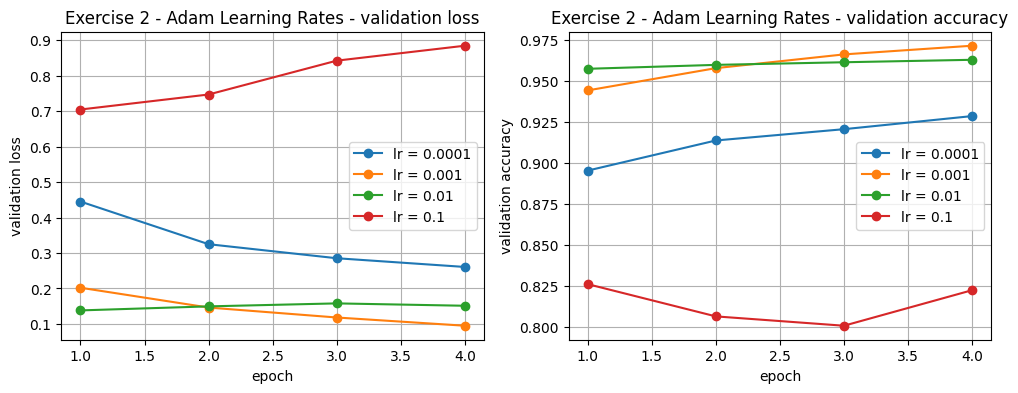

In [33]:
# Exercise 2 (b)
plot_comparison(ex2_results, "Exercise 2 - Adam Learning Rates")

**(c) For each learning rate, print the final validation loss and the final validation accuracy.** [5 marks]

In [34]:
# Exercise 2 (c)
for name, history in ex2_results.items():
    final_loss = history["val_loss"][-1]
    final_acc = history["val_acc"][-1]
    print(f"{name} -> final validation loss: {final_loss:.3f}, final validation accuracy: {final_acc:.4f}")

lr = 0.0001 -> final validation loss: 0.261, final validation accuracy: 0.9286
lr = 0.001 -> final validation loss: 0.095, final validation accuracy: 0.9716
lr = 0.01 -> final validation loss: 0.151, final validation accuracy: 0.9630
lr = 0.1 -> final validation loss: 0.884, final validation accuracy: 0.8222


**(d) Answer using your plot and your numbers.** [10 marks]

1. Which learning rate gives the best final validation accuracy? [2 marks]
2. Describe the curve for lr = 0.0001. Is this learning rate too small, good, or too large? Give the reason. [4 marks]
3. Describe the curve for lr = 0.1. Is this learning rate too small, good, or too large? Give the reason. [4 marks]

**YES AND A LITTTLE BIT TRICK HERE:**

1.lr = 0.001 gives the best final validation accuracy.

2 The curve for lr = 0.0001 decreases smoothly, but the overall progress is slow. This learning rate is too small because step sizes are tiny, leaving the model underfitted and far from optimal accuracy within 4 epochs.

3 The curve for lr = 0.1 stays flat at high loss and low accuracy (around 10%). This learning rate is too large because the step updates are huge, causing the weight optimization to overshoot and destabilize, preventing the network from learning.

